## 1. Import Necessary Packages

In [54]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
import numpy as np
import kaggle
import matplotlib.pyplot as plt
import pandas as pd
import librosa
from pathlib import Path
from mutagen.mp3 import MP3
from mutagen import MutagenError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from collections import Counter

## 2. Define Default Values

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataFolder = './data'
dataPath = Path(dataFolder)

## 3. Download Data
In this, I will be using the [FMA Medium dataset](https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium).
Ensure that you have set your kaggle api token as an environment variable (KAGGLE_API_TOKEN) amd have enough storage for this dataset (34.26 GB).
I made this automatically check if the `./data` folder exists and skips the download if it does to prevent repeated downloadeds, to avoid this, just delete the `./data` folder when you need to redownload.

In [14]:
if not dataPath.exists():
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('imsparsh/fma-free-music-archive-small-medium', path=dataFolder, unzip=True)

## 4. Clean and Prepare Data
Get genre names and create Dataset class to read the files. Rather than loading all 34GB into memory, this will pull the files at read time.

### Load Metadata

In [ ]:
datasetPath = Path(f'{dataFolder}/fma_medium/fma_medium')
numGenres = sum(1 for x in datasetPath.iterdir() if x.is_dir())
print(f'Number of genres: {numGenres}')
df = pd.read_csv(f'{dataFolder}/fma_metadata/genres.csv')
print(df.describe)
genres = df['title'][:numGenres]
genresNumbered = [i for i in range(numGenres)]
# Make sure there are not more file genres than metadata genres
assert(genres.shape[0] == numGenres)

Number of genres: 156
<bound method NDFrame.describe of      genre_id  #tracks  parent          title  top_level
0           1     8693      38    Avant-Garde         38
1           2     5271       0  International          2
2           3     1752       0          Blues          3
3           4     4126       0           Jazz          4
4           5     4106       0      Classical          5
..        ...      ...     ...            ...        ...
158      1032       60     102        Turkish          2
159      1060       30      46          Tango          2
160      1156       26     130           Fado          2
161      1193       72     763      Christmas         38
162      1235    14938       0   Instrumental       1235

[163 rows x 5 columns]>


### Create Custom Dataset

In [ ]:
class CustomDataset(Dataset):
    def __init__(
            self, 
            path: Path, 
            log_mels: bool,
            cqt: bool,
            sample_rate: int = 22050, 
            duration: float = 30.0, 
            n_mels: int = 128,
            n_bins: int = 84,
            bins_per_octave: int = 12,
            n_fft: int = 2048,
            hop_length: int = 512,
            cache_dir: str = None,
            transform: transforms = None,
            num_workers: int = 4
        ):
        # dataset
        self.video_labels = []
        self.path = path
        self.transform = transform
        self.video_paths = []
        self.num_workers = num_workers

        # spectrogram values
        self.log_mels = log_mels
        self.cqt = cqt
        if not cqt and not log_mels:
            raise ValueError("log_mels or cqt must be true.")
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_mels = n_mels
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.n_fft = n_fft
        self.hop_length = hop_length

        # cache
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

        # stats
        self.lm_mean = 0.0
        self.lm_std = 0.0
        self.cqt_mean = 0.0
        self.cqt_std = 0.0

        self.load_dataset()

    def is_valid_mp3(self, path: str) -> bool:
        try:
            audio = MP3(path)
            return audio.info.length > 0
        except (MutagenError, Exception):
            return False

    def load_dataset(self):
        """
        Loads dataset file paths and labels into memory.
        Removes labels that have less than 100 files.
        """
        # Collect all video paths and connect them to their label
        label_dirs = [d for d in self.path.iterdir() if d.is_dir()]
        all_files = []

        for dir in label_dirs:
            label_idx = int(dir.name)
            for item in dir.iterdir():
                # Only care about files that are .mp3
                if item.is_file() and item.suffix == '.mp3':
                    all_files.append((item.resolve(), label_idx))

        def validate(args):
            path, label = args
            return (path, label) if self.is_valid_mp3(path) else None

        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {
                executor.submit(validate, f): f for f in all_files
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Validating"):
                result = future.result()
                if result:
                    path, label = result
                    self.video_labels.append(label)
                    self.video_paths.append(path)
        
        count = Counter(label_idx)
        invalid = set()
        for key, amt in count.items():
            if amt < 100:
                invalid.add(key)
        self.video_paths = [val for i, val in enumerate(self.video_paths) if self.video_labels[i] not in invalid]
        self.video_labels = [val for val in self.video_labels if val not in invalid]
        # Update values
        numGenres -= len(invalid)
        genresNumbered = [genre for genre in genresNumbered if genre not in invalid]
        print(invalid)
        print(numGenres - len(invalid))
        print(len(self.video_paths))
        print(len(self.video_labels))
        

    def cache_idx(self, idx: int) -> bool:
        try:
            self.__getitem__(idx)
            return True
        except:
            return False

    def precache_all(self) -> list[str]:
        if not self.cache_dir:
            return []

        N = len(self.video_labels)
        success = [False] * N
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {
                executor.submit(self.cache_idx, i):i for i in range(N)
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Caching"):
                i = futures[future]
                success[i] = future.result()
        self.video_labels = [self.video_labels[i] for i in range(N) if success[i]]
        self.video_paths = [self.video_paths[i] for i in range(N) if success[i]]
        return [i for i in range(N) if not success[i]]

    def mp3_to_log_mel(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.sample_rate * self.duration)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0,1]
        log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)

    def mp3_to_cqt(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.duration * self.sample_rate)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        cqt = librosa.cqt(
            y=audio,
            sr=self.sample_rate,
            n_bins = self.n_bins,
            bins_per_octave = self.bins_per_octave,
            hop_length=self.hop_length,
            fmin=librosa.note_to_hz('C1')
        )

        # Normalize to [0,1]
        log_cqt = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
        log_cqt = (log_cqt-log_cqt.min())/(log_cqt.max()-log_cqt.min()+1e-8)
        return log_cqt.astype(np.float32)
        

    def load_and_compute_lm(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_lm_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        lm_spec = self.mp3_to_log_mel(path)

        if self.cache_dir:
            np.save(cache_path, lm_spec)

        return lm_spec
    
    def load_and_compute_cqt(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_cqt_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        cqt_val = self.mp3_to_cqt(path)

        if self.cache_dir:
            np.save(cache_path, cqt_val)
        
        return cqt_val

    def __len__(self) -> int:
        return len(self.video_labels)
    
    # Commented out values were used to calculate mean and std
    def __getitem__(self, idx: int) -> np.ndarray:
        label = self.video_labels[idx]
        vid = self.video_paths[idx]
        if self.log_mels and self.cqt:
            lm_spect = self.load_and_compute_lm(vid)
            # self.lm_mean += lm_spect.reshape(-1).mean()
            # self.lm_std += lm_spect.reshape(-1).std()
            cqt_spect = self.load_and_compute_cqt(vid)
            # self.cqt_mean += cqt_spect.reshape(-1).mean()
            # self.cqt_std += cqt_spect.reshape(-1).mean()
            cqt_spect_padded = np.pad(cqt_spect, ((0, self.n_mels - self.n_bins), (0, 0)))
            stacked_output = np.stack([lm_spect, cqt_spect_padded], axis=0)
            stacked_output = torch.tensor(stacked_output, dtype=torch.float32)
            if self.transform:
                stacked_output = self.transform(stacked_output)
            return stacked_output, label
        elif self.log_mels:
            lm_spect = self.load_and_compute_lm(vid)
            lm_spect = torch.tensor(lm_spect, dtype=torch.float32).unsqueeze(0)
            if self.transform:
                lm_spect = self.transform(lm_spect)
            return lm_spect, label
        cqt_spect = self.load_and_compute_cqt(vid)
        cqt_spect = torch.tensor(cqt_spect, dtype=torch.float32).unsqueeze(0)
        if self.transform:
            cqt_spect = self.transform(cqt_spect)
        return cqt_spect, label

### Load Dataset

In [51]:
# Calculated mean and std values [lm_val, cqt_val]
augment = transforms.Compose([
    transforms.Normalize(
        mean=[0.3453841805458069, 0.3439251780509949],
        std=[0.092504121363163, 0.3506147861480713]
    ),
    transforms.RandomErasing(p=0.3),   # SpecAugment-style masking
])
cache = './cache'
ds = CustomDataset(datasetPath, True, True, cache_dir=cache, transform=augment)

# Precaching will help to validate that all the .mp3 files are accessible.
ds.precache_all()

test_ds, train_ds, val_ds = random_split(ds, lengths=[0.15, 0.70, 0.15])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

Caching:  63%|██████▎   | 15620/24985 [00:36<00:22, 424.23it/s]C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_13572\39633550.py:110: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
d:\anaconda3\envs\ai-genre\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Caching: 100%|██████████| 24985/24985 [00:57<00:00, 431.73it/s]


In [53]:
from collections import Counter
c = Counter(ds.video_labels)
for k in c:
    print(f"{k}: {c[k]}")

0: 199
1: 215
2: 5
3: 196
4: 240
5: 129
6: 151
7: 116
8: 78
9: 94
10: 230
11: 267
12: 202
13: 158
14: 269
15: 142
16: 214
17: 169
18: 136
19: 187
20: 192
21: 170
22: 140
23: 159
24: 177
25: 103
26: 160
27: 140
28: 135
29: 145
30: 135
31: 117
32: 184
33: 134
34: 95
35: 91
36: 170
37: 119
38: 150
39: 109
40: 206
41: 124
42: 208
43: 166
44: 141
45: 115
46: 159
47: 184
48: 187
49: 95
50: 141
51: 202
52: 178
53: 115
54: 243
55: 213
56: 178
57: 205
58: 119
59: 201
60: 197
61: 122
62: 168
63: 237
64: 243
65: 144
66: 264
67: 187
68: 180
69: 191
70: 173
71: 326
72: 165
73: 156
74: 153
75: 242
76: 113
77: 64
78: 73
79: 92
80: 132
81: 115
82: 188
83: 118
84: 124
85: 156
86: 125
87: 174
88: 63
89: 75
90: 94
91: 279
92: 119
93: 138
94: 111
95: 117
96: 128
97: 185
98: 225
99: 199
100: 59
101: 52
102: 48
103: 32
104: 107
105: 151
106: 103
107: 217
108: 254
109: 180
110: 190
111: 221
112: 165
113: 232
114: 189
115: 163
116: 233
117: 124
118: 200
119: 136
120: 185
121: 161
122: 287
123: 268
124: 196
12

In [50]:
print(len(ds))
mean = (np.array([ds.lm_mean, ds.cqt_mean]) / len(ds.video_paths)).tolist()
std = (np.array([ds.lm_std, ds.cqt_std]) / len(ds.video_paths)).tolist()
print(f"mean: {mean}, std: {std}")

24979
mean: [0.3453841805458069, 0.3439251780509949], std: [0.092504121363163, 0.3506147861480713]


### View dataset

Label: 70 — Shape: torch.Size([2, 128, 1292])


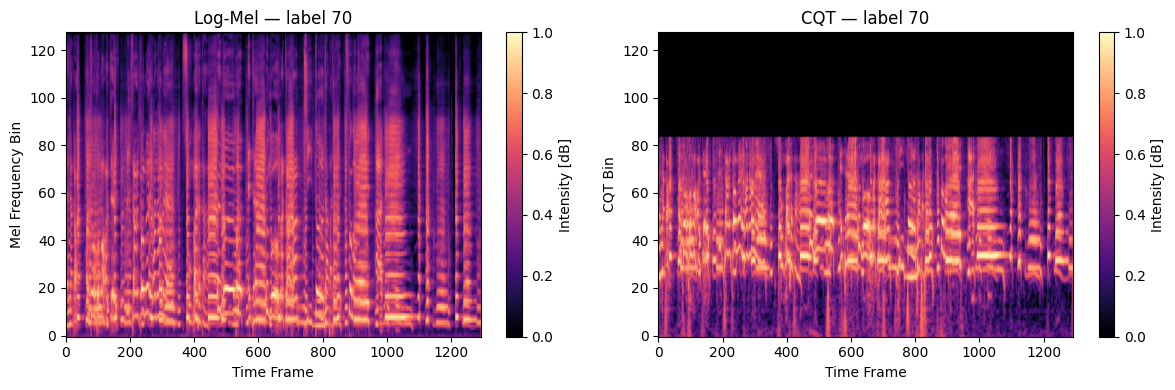

Label: 48 — Shape: torch.Size([2, 128, 1292])


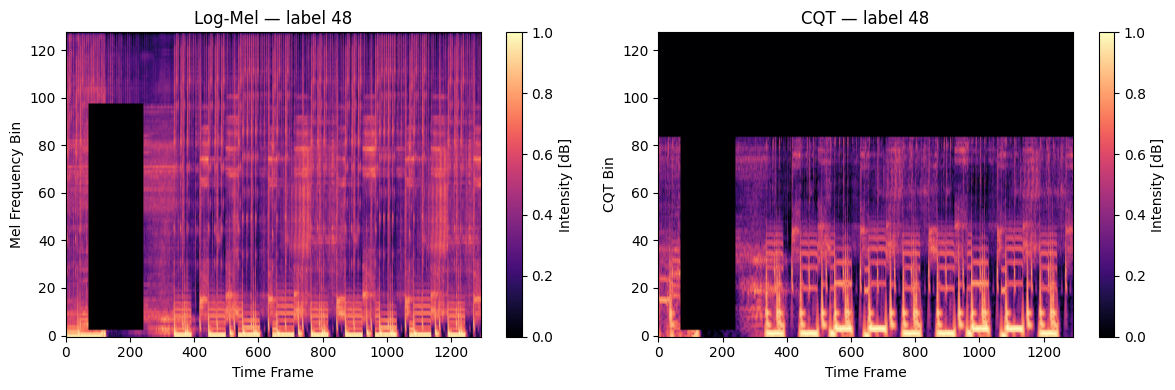

In [ ]:
def visualize_dataset(loader, ds):
    data = next(iter(loader))
    inputs, labels = data
    N = 2

    for i in range(N):
        input = inputs[i]   # (C, 128, T) where C is 1 or 2
        label = labels[i].item()
        print(f"Label: {label} — Shape: {input.shape}")

        n_channels = input.shape[0]
        fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 4))

        # Ensure axes is always iterable even if n_channels == 1
        if n_channels == 1:
            axes = [axes]

        titles = []
        if ds.log_mels:
            titles.append(('Log-Mel', 'Mel Frequency Bin'))
        if ds.cqt:
            titles.append(('CQT', 'CQT Bin'))

        for ax, channel, (title, ylabel) in zip(axes, range(n_channels), titles):
            im = ax.imshow(input[channel], origin='lower', aspect='auto', cmap='magma')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Time Frame')
            ax.set_title(f'{title} — label {label}')
            fig.colorbar(im, ax=ax, label='Intensity [dB]')

        plt.tight_layout()
        plt.show()

visualize_dataset(train_loader, ds)

## 5. Create the Network

### Model

In [ ]:
model = torchvision.models.resnet50(pretrained=True)
# Replace first conv — pretrained weights expect 3 channels
model.conv1 = torch.nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = torch.nn.Linear(model.fc.in_features, numGenres)  # 156 genres

d:\anaconda3\envs\ai-genre\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\envs\ai-genre\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 6. Train the Network

### Testing and Accuracy Functions

In [26]:
def check_accuracy(loader, model) -> float:
    print("Checking Accuracy")
    model = model.to(device=device)
    num_correct = num_samples = 0
    model.eval()
    with torch.no_grad():
        for input, label in loader:
            x = input.to(device=device)
            y = label.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}")
    return float(num_correct)/float(num_samples)

def train_model(train_loader, valid_loader, model, optimizer, loss_fn, epochs) -> float:
    model = model.to(device=device)
    for e in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for input, label in tqdm(train_loader, total=len(train_loader), desc="Batch"):
            model.train()
            x = input.to(device=device)
            y = label.to(device=device)

            score = model(x)
            loss = loss_fn(score, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1
        avg_loss = epoch_loss / num_batches
        print(f"Epoch {e+1}/{epochs}, Loss: {avg_loss:.4f}")
        check_accuracy(valid_loader, model)
        print()
    return check_accuracy(valid_loader, model)

In [ ]:
# Set device
model = model.to(device)

# Define functions and values to be used for training
optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-2},  # new, train faster
    {'params': model.layer1.parameters(), 'lr': 1e-3},
    {'params': model.layer2.parameters(), 'lr': 1e-3},
    {'params': model.layer3.parameters(), 'lr': 1e-3},
    {'params': model.layer4.parameters(), 'lr': 1e-3},
    {'params': model.fc.parameters(), 'lr': 1e-2},     # new, train faster
], lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 20
torch.cuda.empty_cache()
# Train the model
accuracy = train_model(train_loader, val_loader, model, optimizer, loss_fn, epochs)
print(f'Final validation accuracy: {accuracy:.2f}')

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.0.conv3.weight True
layer1.0.bn3.weight True
layer1.0.bn3.bias True
layer1.0.downsample.0.weight True
layer1.0.downsample.1.weight True
layer1.0.downsample.1.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer1.1.conv3.weight True
layer1.1.bn3.weight True
layer1.1.bn3.bias True
layer1.2.conv1.weight True
layer1.2.bn1.weight True
layer1.2.bn1.bias True
layer1.2.conv2.weight True
layer1.2.bn2.weight True
layer1.2.bn2.bias True
layer1.2.conv3.weight True
layer1.2.bn3.weight True
layer1.2.bn3.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.conv3.weight True


Batch: 100%|██████████| 2186/2186 [11:11<00:00,  3.26it/s]


Epoch 1/20, Loss: 4.9772
Checking Accuracy
Got 46 / 3746 with accuracy 1.23



Batch:   0%|          | 2/2186 [00:01<18:56,  1.92it/s]


KeyboardInterrupt: 

## 7. Test the Network

In [ ]:
train_acc = check_accuracy(test_loader, model)
print(f"Testing accuracy: {train_acc:.2f}")